##  Primero vamos a ver como son los datos


In [1]:
import pandas as pd
import numpy as np

In [2]:
spam_data = pd.read_csv('spam_ham_dataset.csv')

In [3]:
spam_data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
#La columna text no se ve bien vamos a ver en el primer registro que hay en la columna text
print(spam_data['text'][0])

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .


## Vamos a ver si hay valores nulos, y su dimension

In [5]:
spam_data.describe()

,Unnamed: 0,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


In [6]:
#Dimension de los datos
spam_data.shape

(5171, 4)

In [7]:
spam_data.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

## No hay valores nulos, asi que perfecto

In [8]:
distribucion = spam_data["label_num"].value_counts()

In [9]:
import matplotlib.pyplot as plt

<BarContainer object of 2 artists>

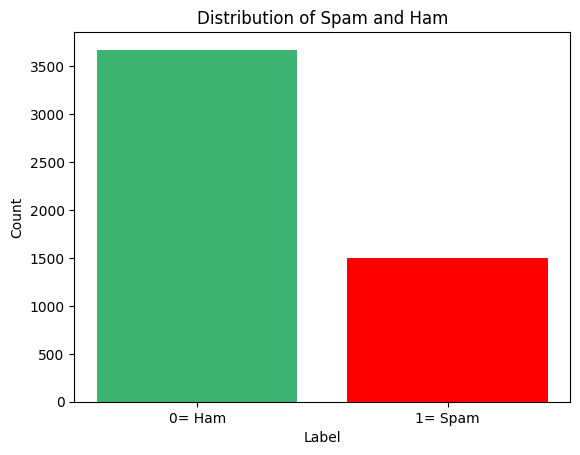

In [10]:
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Spam and Ham')
plt.xticks([0, 1], ['0= Ham', '1= Spam'])
plt.bar(distribucion.index, distribucion.values, color=['mediumseagreen', 'red'])

### Como hay muchos muestras ham que spam, para que no se incline el modelo por la clase ham, lo pondremos al mismo nivel de muestras

In [11]:
ham_data = spam_data[spam_data['label_num'] == 0]
spam_data = spam_data[spam_data['label_num'] == 1]

In [12]:
ham_balanced_data = ham_data.sample(n=len(spam_data), random_state=42)

In [13]:
combined_data = pd.concat([ham_balanced_data, spam_data]).reset_index(drop=True)
combined_data

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject: conoco - big cowboy\r\ndarren :\r\ni ...,0
1,2982,ham,Subject: feb 01 prod : sale to teco gas proces...,0
2,2711,ham,Subject: california energy crisis\r\ncaliforni...,0
3,3116,ham,Subject: re : nom / actual volume for april 23...,0
4,1314,ham,Subject: eastrans nomination changes effective...,0
...,...,...,...,...
2993,4381,spam,Subject: pictures\r\nstreamlined denizen ajar ...,1
2994,4979,spam,Subject: penny stocks are about timing\r\nnoma...,1
2995,4162,spam,Subject: anomaly boys from 3881\r\nuosda apapr...,1
2996,4365,spam,Subject: slutty milf wants to meet you\r\ntake...,1


In [14]:
distribucion_balanced = combined_data["label_num"].value_counts()

<BarContainer object of 2 artists>

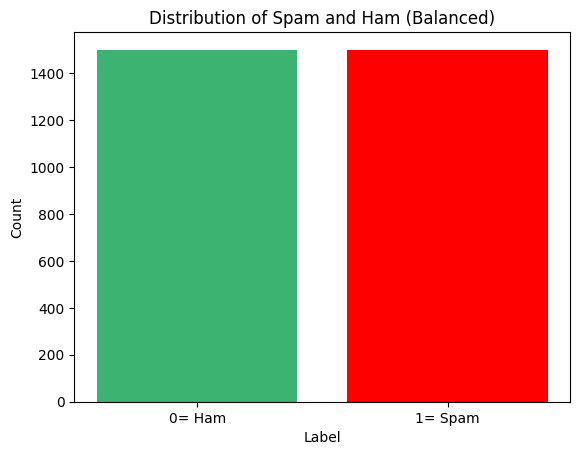

In [15]:
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Spam and Ham (Balanced)')
plt.xticks([0, 1], ['0= Ham', '1= Spam'])
plt.bar(distribucion_balanced.index, distribucion_balanced.values, color=['mediumseagreen', 'red'])

## Ahora comenzamos nuestro preprocesamiento

Empezaremos quitando los stopWords, que son palabras que no aportan valor semantico a los analisis de texto. No siempre es bueno quitarlos, en este caso para analisis de si es spam o no, no aportan muchos significado a nuestro problema, luego podemos quitarlos.
También eliminaremos los caracteres de puntuacion. (! " # $ % & ' ( ) * + , - . / : ; ? @ [ \ ] ^ _ ` { | } ~ )
Y aplicaremos stemming o lemmatization, para coger la parte importante de las palabras.

Lo primero a quitar son los asuntos de los mensajes

In [16]:
combined_data['text'] = combined_data['text'].str.replace('Subject', '')
combined_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [17]:
import string
punctuations_list = string.punctuation
punctuations_list

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
def remove_punctuation(text):
    text_without_punctuation = str.maketrans("", "", punctuations_list)
    return text.translate(text_without_punctuation)

combined_data['text'] = combined_data['text'].apply(remove_punctuation)
combined_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [19]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\felix\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    array_of_words = [word.lower() for word in text.split() if word.lower() not in stop_words]
    return ' '.join(array_of_words)

combined_data['text'] = combined_data['text'].apply(remove_stopwords)
combined_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


## Vamos a ver visualizacion de las palabras mas usadas con word cloud

In [21]:
from wordcloud import WordCloud

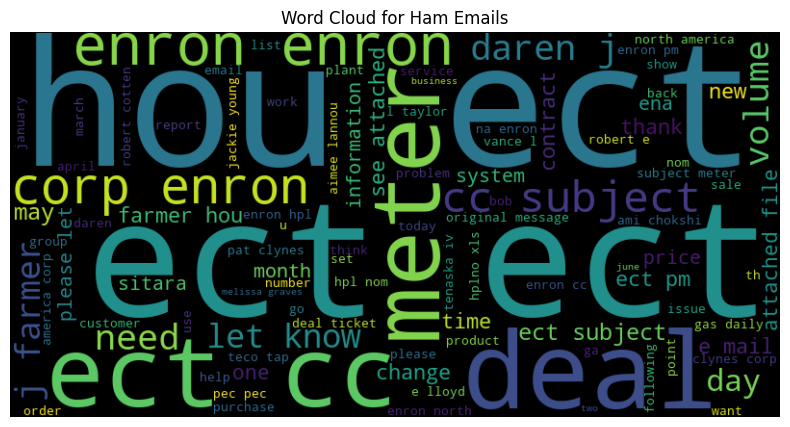

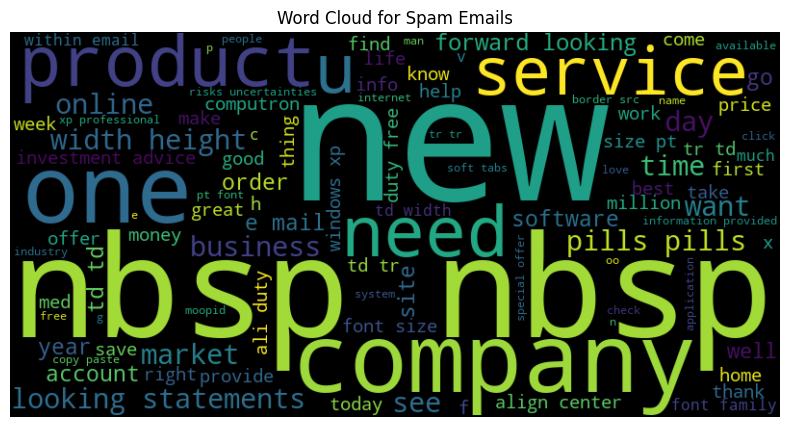

In [22]:
def plot_wordcloud(data, typ):
    texto_emails = ' '.join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(texto_emails)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear') # Para que se vea bien la imagen
    plt.axis('off')
    plt.title(f'Word Cloud for {typ} Emails')
    plt.show()

plot_wordcloud(combined_data[combined_data['label_num'] == 0], 'Ham')
plot_wordcloud(combined_data[combined_data['label_num'] == 1], 'Spam')

## Ahora tokenizamos y usamos padding para asegurar que todas las secuencias de texto son de la misma longitud

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [24]:
train_X, test_X, train_y, test_y = train_test_split(combined_data['text'], combined_data['label_num'], test_size=0.2, random_state=42)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

In [25]:
train_vector = tokenizer.texts_to_sequences(train_X)
test_vector = tokenizer.texts_to_sequences(test_X)


In [26]:
max_len = 100  # Define the maximum length for padding
train_vector = pad_sequences(train_vector, maxlen=max_len, padding='post', truncating='post') # Esto para pasarle siempre un vector de tamaño fijo a la red neuronal, ya que no puede recibir vectores de tamaño variable
test_vector = pad_sequences(test_vector, maxlen=max_len, padding='post', truncating='post')

## Y empezamos nuestro entrenamiento del modelo

Vamos a usar un modelo de deep learning, usando un embedding, un LSTM y capas Dense para razonar con el contexto del correo si es spam o no

In [27]:
train_vector

array([[ 306,   48,  417, ...,    0,    0,    0],
       [ 713,  241,  523, ...,    0,    0,    0],
       [1710,   48,  209, ...,    0,    0,    0],
       ...,
       [ 359, 1059,  830, ...,  385,  683,  745],
       [   3,  373,  288, ...,    0,    0,    0],
       [1829,    5,  107, ..., 1555, 1128, 1915]],
      shape=(2398, 100), dtype=int32)

In [28]:
len(tokenizer.word_index)

39840

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len), # El + 1 es por el token 0 que es el padding.
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') #Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\felix\OneDrive\Escritorio\ML\ml-geekforgeeks\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Y entrenamos

In [30]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_vector, train_y,
    validation_data=(test_vector, test_y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5834 - loss: 0.6881 - val_accuracy: 0.6367 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9008 - loss: 0.3227 - val_accuracy: 0.9567 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9554 - loss: 0.1754 - val_accuracy: 0.9667 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9600 - loss: 0.1590 - val_accuracy: 0.9650 - val_loss: 0.1341 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9700 - loss: 0.1196 - val_accuracy: 0.9633 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9771 - loss: 0.1017 - val_accuracy: 0.9700 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9821 - loss: 0.0839 - val_acc

In [31]:
test_loss, test_accuracy = model.evaluate(test_vector, test_y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9783 - loss: 0.1050
Test Loss : 0.10503735393285751
Test Accuracy : 0.9783333539962769


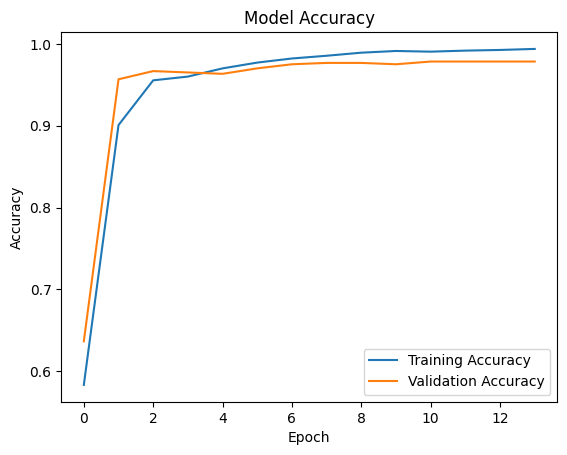

In [32]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Intento de ver la curva ROC

In [37]:
y_pred_keras = model.predict(test_vector).ravel()  # Flatten the predictions to a 1D array
y_pred_keras

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([0.00392175, 0.00423154, 0.00392176, 0.9748596 , 0.00419422,
       0.00392175, 0.97505623, 0.00392177, 0.9876604 , 0.97456336,
       0.9748617 , 0.00392202, 0.9748533 , 0.98789805, 0.00392175,
       0.9748933 , 0.97518754, 0.00393795, 0.9906969 , 0.97453696,
       0.97516406, 0.00392513, 0.00392173, 0.9749672 , 0.00392175,
       0.97477794, 0.00392174, 0.9757307 , 0.9749046 , 0.00392175,
       0.9748675 , 0.00392177, 0.00404067, 0.00392176, 0.9748777 ,
       0.9749389 , 0.978135  , 0.00392175, 0.00406263, 0.00392175,
       0.00392176, 0.00392175, 0.9890675 , 0.00392175, 0.00392179,
       0.00392245, 0.00414206, 0.00418604, 0.97494024, 0.0039218 ,
       0.00392176, 0.97489107, 0.9748867 , 0.00391731, 0.9748669 ,
       0.97489876, 0.9748603 , 0.9752295 , 0.00392176, 0.99396783,
       0.00392175, 0.00392175, 0.9750701 , 0.00392175, 0.00425167,
       0.98880804, 0.99239707, 0.9749351 , 0.97498196, 0.0039218 ,
       0.00392194, 0.00392176, 0.97489953, 0.00392175, 0.00424

In [38]:
y_pred_keras.shape

(600,)

In [41]:
test_y

1376    0
932     0
144     0
1752    1
51      0
       ..
637     0
695     0
226     0
2260    1
1103    0
Name: label_num, Length: 600, dtype: int64

In [42]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(test_y, y_pred_keras)

In [44]:
auc_keras = auc(fpr, tpr)
auc_keras

0.9829351155666944

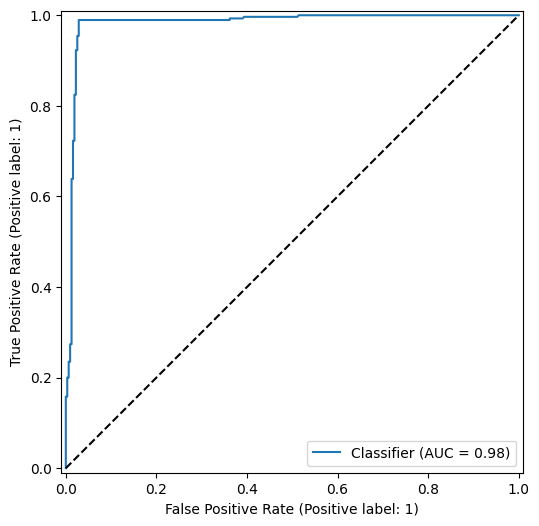

In [46]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    test_y,
    y_pred_keras,
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)')

plt.show()

Usaremos el indice de youden, que es para encontrar el punto maximo de distancia de tpr y menor de fpr, restando tpr - fpr

In [51]:
youden_scores = tpr - fpr

In [53]:
idx_optimo = np.argmax(youden_scores)
idx_optimo

np.int64(31)

In [54]:
print(f"Mejor threshold de {thresholds[idx_optimo]}")
print(f"Con un tpr de {tpr[idx_optimo]} y un fpr de {fpr[idx_optimo]}")

Mejor threshold de 0.9735580086708069
Con un tpr de 0.9894736842105263 y un fpr de 0.02857142857142857
